In [1]:
save_data = False

In [2]:
import importlib
import torch
import PCA_law
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from time import sleep

importlib.reload(PCA_law)

from PCA_law import PCA_law, PCA_classifier


In [3]:
torch.cuda.is_available()

True

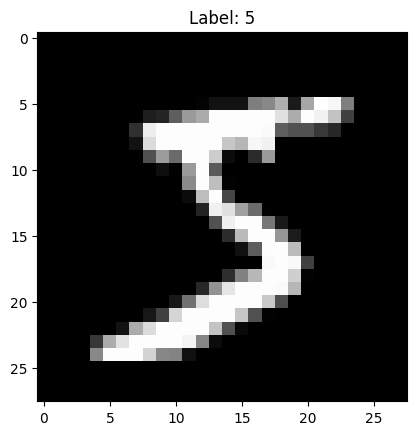

In [4]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root='data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='data', train=False, download=True, transform=transform)

# Example image
img, label = mnist_train[0]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()


In [5]:
# 2) Choose device/dtype once
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32   # faster on GPU; use float64 if you need extra numerical stability

# 3) Flatten, normalize, and move EVERYTHING once
X_train = mnist_train.data.view(len(mnist_train), -1).to(device=device, dtype=dtype) / 255.0   # [60000, 784]
y_train = mnist_train.targets.to(device=device, dtype=torch.long)

X_test  = mnist_test.data.view(len(mnist_test), -1).to(device=device, dtype=dtype) / 255.0     # [10000, 784]
y_test  = mnist_test.targets.to(device=device, dtype=torch.long)

# 4) Import your PCA classifier (the nn.Module / buffer-based version)
# from torch_pca_classifier import PCA_classifier
# (paste the class definitions into scope if not using a module file)

clf = PCA_classifier(n_components=40, center=True, dtype=dtype)

# 5) Fit once on the whole training set (28*28=784 so eigendecomp is tiny)
with torch.inference_mode():  # no gradients anywhere
    clf.fit(X_train, y_train)

# 6) Predict on the whole test set at once (fastest)
with torch.inference_mode():
    y_pred_test = clf.predict(X_test, return_numpy=False)   # tensor on device
    y_pred_train = clf.predict(X_train, return_numpy=False)   # tensor on device

# 7) Accuracy
acc_test = (y_pred_test == y_test).float().mean().item()
acc_train = (y_pred_train == y_train).float().mean().item()
print(f"Train accuracy: {acc_train*100:.2f}%")
print(f"Test accuracy: {acc_test*100:.2f}%")


Train accuracy: 95.73%
Test accuracy: 95.62%


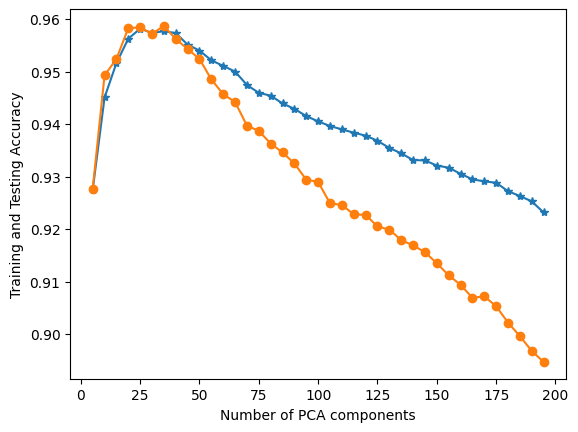

In [6]:
results = []
R = range(5, 200, 5)
Rlen = len(R)
for i,n_components in enumerate(range(5, 200, 5)):
    print(f'{n_components:4d} -- {i+1:3d}/{Rlen} -> {100*(i+1)/Rlen:.1f}%', end='\r')
    clf = PCA_classifier(n_components=n_components, center=True, dtype=dtype)

    # 5) Fit once on the whole training set (28*28=784 so eigendecomp is tiny)
    with torch.inference_mode():  # no gradients anywhere
        clf.fit(X_train, y_train)

    # 6) Predict on the whole test set at once (fastest)
    with torch.inference_mode():
        y_pred_test = clf.predict(X_test, return_numpy=False)   # tensor on device
        y_pred_train = clf.predict(X_train, return_numpy=False)   # tensor on device

    # 7) Accuracy
    acc_train = (y_pred_train == y_train).float().mean().item()
    acc_test = (y_pred_test == y_test).float().mean().item()
    results.append((n_components, acc_train, acc_test))
results = np.array(results)
plt.plot(results[:,0], results[:,1], "*-")
plt.plot(results[:,0], results[:,2], "o-")
plt.xlabel("Number of PCA components")
plt.ylabel("Training and Testing Accuracy")
plt.show()


label=5


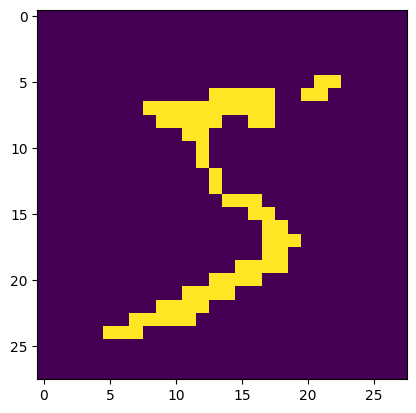

In [38]:
plt.imshow(X_train[0]>0.9)
print(f'label={y_train[0]}')

In [32]:
X0 = X_train[y_train==0]
X1 = X_train[y_train!=0]

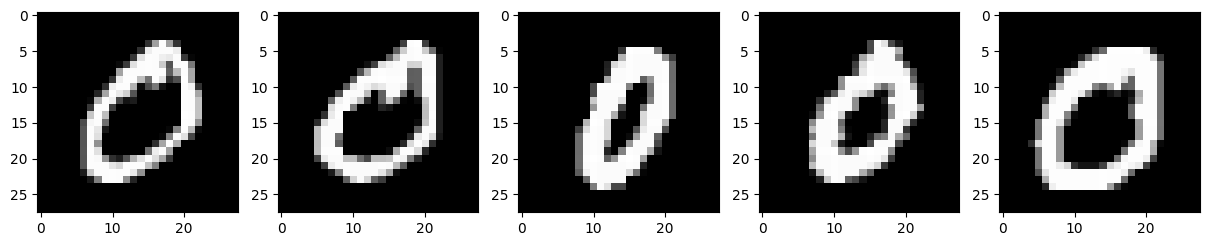

In [13]:
ncols=5
fig, ax = plt.subplots(1, ncols, figsize=(3*ncols, 3))
for i in range(ncols):
    ax[i].imshow(X0[i], cmap='gray')

In [42]:
n_components = 35
npart = 5
ndata = X0.shape[0]//npart
print('len(ndata)=', ndata )
pclaw = []
for n in range(npart):
    pclaw.append(PCA_law(n_components= n_components))
    pclaw[-1].fit(X0[n:n+ndata].reshape(-1,28*28))
    print(pclaw[-1].chi2(X0[n:n+ndata].reshape(-1,28*28)).mean())

len(ndata)= 1184
0.40878433
0.40878436
0.4087844
0.4087844
0.4087843


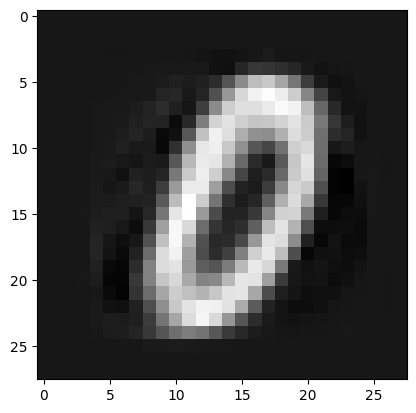

In [36]:
pp0 = pclaw[-1].compress(X0[2].reshape(-1,28*28))
xrecon = pclaw[-1].reconstruct(pp0).reshape(28,28)
plt.imshow(xrecon, cmap='gray')

In [39]:
[np.mean(pp.chi2(X0.reshape(-1,28*28), ep=1e-30)) for pp in pclaw]  

[np.float32(8.178415e+26),
 np.float32(8.178415e+26),
 np.float32(8.178415e+26),
 np.float32(8.178415e+26),
 np.float32(8.178415e+26)]

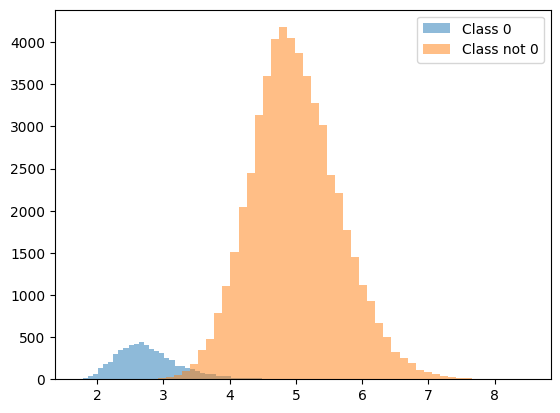

In [33]:
u = pclaw.classify(X0.reshape(-1,28*28))
v = pclaw.classify(X1.reshape(-1,28*28))
plt.hist(u, bins=50, alpha=0.5, label='Class 0')
plt.hist(v, bins=50, alpha=0.5, label='Class not 0')
plt.legend()
plt.show()